## Предварительный анализ данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.formula.api as smf
import statsmodels.api as sm
warnings.filterwarnings('ignore')

### Предварительная обработка

In [2]:
data = pd.read_csv('https://dano.hse.ru/mirror/pubs/share/872857574')
data.head(5)

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0
3,1500364601,5-1VA0D94LX,2022-10-23,29688,Скидки,1204914,GTFO,1675.01,1.0,M,24,GRD,Самара,56000,283.0
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0


In [3]:
data.isna().sum() ## нет пропусков в данных

id                        0
client_id                 0
order_day                 0
category_id               0
category_name             0
good_id                   0
good_name                 0
good_price                0
good_cnt                  0
gender_cd                 0
age                       0
education_level           0
city_nm                   0
monthly_income_amt        0
steam_popularity_score    0
dtype: int64

In [4]:
data['order_day'] = pd.to_datetime(data['order_day'], format='mixed') ## перевод данных в datetime

#### Удаление выбросов в данных

In [5]:
data = data[data['age'] >= 14] ## если человеку меньше 14 лет, то он не сможет самостоятельно делать покупки, т.к у него не будет взрослой карты
data

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0
3,1500364601,5-1VA0D94LX,2022-10-23,29688,Скидки,1204914,GTFO,1675.01,1.0,M,24,GRD,Самара,56000,283.0
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88694,1500300796,5-355R05SQ3,2022-07-23,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,18,SCH,Москва,170486,0.0
88695,1500302138,5-2IKJ0HXNU,2022-07-25,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,19,UGR,Самара,38000,0.0
88696,1500351510,5-8EVSLK13,2022-10-05,28577,Экшн,1406123,Dome Keeper - Deluxe Edition,561.60,1.0,M,33,SCH,Краснодар,230000,0.0
88697,1500476540,5-122LQCE7M,2023-02-13,28574,Ролевые (RPG),848895,Gothic Universe Edition,59.80,1.0,M,37,GRD,Москва,170000,0.0


#### Проверка столбца education_level

In [6]:
data['education_level'].value_counts() ## видно, что большая часть покупок совершается людьми с высшим или неполным высшим образованием, подозрительно

education_level
GRD    37869
SCH    28165
UGR    18959
PGR     1352
ACD      232
Name: count, dtype: int64

In [7]:
## есть подозрение на то, что данные столбца education_level не информативны
## возьмем рандомного человека
data[data['client_id'] == '5-2IKJ0HXNU']
## видим, что у него как-то слишком часто меняется уровень образования ЗА ГОД (есть SCH GRD UGR), что невозможно

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score
1425,1500300108,5-2IKJ0HXNU,2022-07-22,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,UGR,Самара,38000,0.0
4796,1500298215,5-2IKJ0HXNU,2022-07-19,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,UGR,Самара,38000,0.0
31635,1500297655,5-2IKJ0HXNU,2022-07-18,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,GRD,Самара,38000,0.0
39272,1500297631,5-2IKJ0HXNU,2022-07-18,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,GRD,Самара,38000,0.0
51121,1500305760,5-2IKJ0HXNU,2022-07-31,28577,Экшн,848362,Apex Legends: 4350 Coins,2999.0,1.0,M,19,UGR,Самара,38000,0.0
59953,1500297651,5-2IKJ0HXNU,2022-07-18,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,SCH,Самара,38000,0.0
66292,1500298086,5-2IKJ0HXNU,2022-07-19,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,GRD,Самара,38000,0.0
68452,1500299526,5-2IKJ0HXNU,2022-07-21,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,UGR,Самара,38000,0.0
75403,1500304865,5-2IKJ0HXNU,2022-07-29,33164,Бестселлеры,847404,Apex Legends: 11500 Coins,7499.0,1.0,M,19,GRD,Самара,38000,0.0
78352,1500302879,5-2IKJ0HXNU,2022-07-27,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.0,1.0,M,19,GRD,Самара,38000,0.0


In [8]:
## проверим, насколько часто такое встречается в других данных
## в теории, человек может изменить свое образование за год один раз, но ДВА раза уже точно не сможет
agg_data = data.groupby(by='client_id', as_index=False).agg({'education_level': 'nunique', 'age': 'mean'})
bad_education = agg_data[agg_data['education_level'] > 2]
len(bad_education) ## есть 2000 людей точно с плохими данными по education_level, т.е надо делать выводы по education_level аккуратнее, без этих людей

2311

In [9]:
len(agg_data[agg_data['education_level'] == 2])
## плюсом к этому, есть 4630 людей, которые поменяли свое образование, что не особо реалистично 

4630

In [10]:
impossible_educ = data[(data['age'] < 21) & ((data['education_level'] == 'GRD') | \
                (data['education_level'] == 'PGR') | (data['education_level'] == 'ACD'))]
len(impossible_educ) ## есть как минимум 8000 людей, которые явно не могли получить такое образование(высшее и лучше)

8697

- Вывод: я бы не использовал данные данного столбца (более 20% плохих данных)
- На будущее - в данных ОЧЕНЬ странно записываются good_name в некоторых случаях.
- Человек в нашем примере покупал валюту Apex Legends(бесплатной игре), но данные записывались в Экшн (мне кажется, что надо создавать отдельную категорию)


#### Исследование данных 

In [11]:
num_users = data['client_id'].nunique()
num_users ## всего 40026 игроков

40026

In [12]:
data['good_price'].max(), data['good_price'].min() 
## все хорошо с данными, т.к минимальная цена положительная, и максимальная цена лежит в разумных передела

(10656.3, 2.32)

In [13]:
data['good_cnt'].value_counts() ## получилоcь что, все столбцы имеют значение 1, поэтому столбец неинформативен

good_cnt
1.0    86577
Name: count, dtype: int64

Text(0, 0.5, 'количество совершенных покупок')

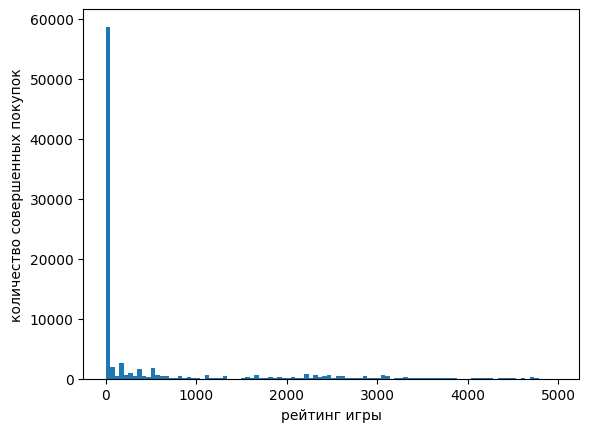

In [14]:
plt.hist(data['steam_popularity_score'], bins=100)
plt.xlabel('рейтинг игры')
plt.ylabel('количество совершенных покупок')

In [15]:
len(data[data['steam_popularity_score'] == 0]) / len(data) ## интересно, что 65% всех покупок пришлись на игры, не имеющие рейтинга(не в топ 5000 игр)
## по логике, люди должны покупать больше игр, у которых больший рейтинг

0.6549198978943599

Text(0, 0.5, 'количество совершенных покупок')

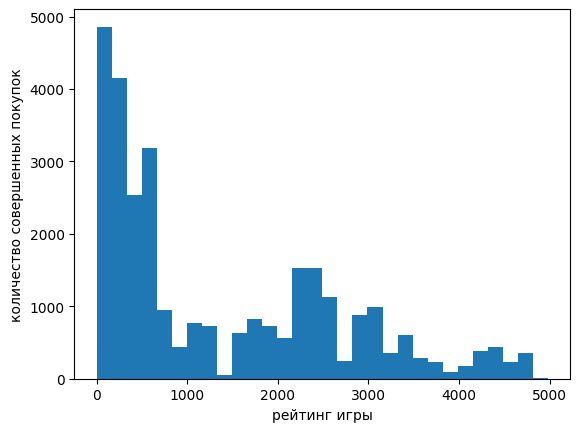

In [16]:
## рассмотрим все игры с рейтингом
plt.hist(data[data['steam_popularity_score'] != 0]['steam_popularity_score'], bins=30)
plt.xlabel('рейтинг игры')
plt.ylabel('количество совершенных покупок')
## на этом графике уже в целом видно, что при увеличении рейтинга кол-ва покупок увеличивается

In [17]:
data['city_nm'].value_counts() ## можем сделать вывод, что в данных есть только лишь крупные города (непонятно почему)  

city_nm
Москва             35948
Санкт-Петербург    18039
Екатеринбург        4519
Новосибирск         4460
Самара              2661
Казань              2508
Краснодар           2455
Нижний Новгород     2382
Ростов-на-Дону      2098
Красноярск          2010
Челябинск           2004
Уфа                 1746
Пермь               1689
Воронеж             1569
Омск                1397
Волгоград           1092
Name: count, dtype: int64

Text(0, 0.5, 'количество совершенных покупок')

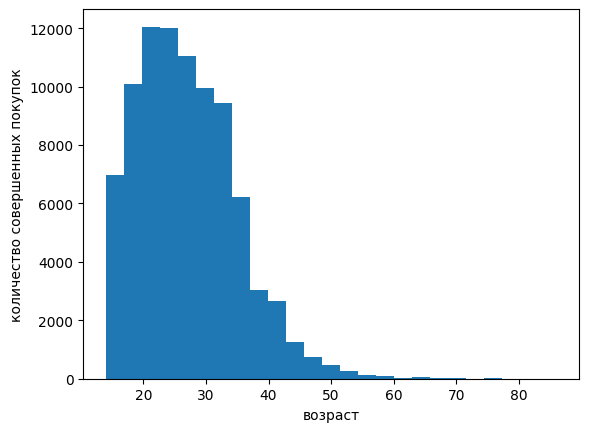

In [18]:
plt.hist(data['age'], bins=25)
plt.xlabel('возраст')
plt.ylabel('количество совершенных покупок')
## можно заметить, что распределение похоже на усеченное нормальное (должно быть более 14 лет)

#### Обработка жанров: Скидки, Бестселлеры, Предзаказы, Новинки

In [19]:
data['category_name'].value_counts() 
## в данных есть такие категории, как Скидки, Бестселлеры, Предзаказы, Новинки которые могут относиться к другим жанрам

category_name
Экшн                       16635
Приключения                10859
Стратегии                  10467
Инди                        9728
Ролевые (RPG)               8275
Симуляторы                  7875
Скидки                      7580
Бестселлеры                 3726
Казуальные игры             2483
Шутеры                      1996
Хоррор                      1592
Гонки                       1429
Файтинги                     654
Аркады                       542
Anime                        501
VR                           435
Новинки                      420
Другое                       370
Спорт                        344
Xbox подписка                278
Классика от Deep Silver      173
Для детей                    102
Карты оплаты                  53
Предзаказы                    42
Онлайн (MMO)                  18
Name: count, dtype: int64

In [20]:
## вместо этого для каждой игры сделаем 4 дополнительных бинарных столбца: Скидки, 
## Бестселлеры, Предзаказы, Новинки, а значения category_name заменим category_name похожих игр

data['is_discount'] = data['category_name'] == 'Скидки'
data['is_bestseller'] = data['category_name'] == 'Бестселлеры'
data['is_new'] = data['category_name'] == 'Новинки'
data['is_preorder'] = data['category_name'] == 'Предзаказы'
data.head(5)

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,True,False,False,False
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0,False,False,False,False
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0,False,False,False,False
3,1500364601,5-1VA0D94LX,2022-10-23,29688,Скидки,1204914,GTFO,1675.01,1.0,M,24,GRD,Самара,56000,283.0,True,False,False,False
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0,False,False,False,False


In [21]:
## возьмем данные, не входящие в новые столбцы
data_not_columns = data[(data['is_discount'] == False) & (data['is_bestseller'] == False) & (data['is_new'] == False) & (data['is_preorder'] == False)]
data_not_columns_modes = data_not_columns.groupby(by='good_name', as_index=False)['category_name'] \
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None) ## берем первое значение если мод несколько
data_not_columns_modes.rename(columns={'category_name': 'true_category_name'}, inplace=True)
data_not_columns_modes

,good_name,true_category_name
0,//N.P.P.D. RUSH// - The milk of Ultraviolet,Экшн
1,//SNOWFLAKE TATTOO//,Инди
2,11-11 Memories Retold,Приключения
3,112 Operator,Симуляторы
4,15 Days,Приключения
...,...,...
3032,Подписка Xbox LIVE GOLD на 3 месяца,Другое
3033,Пополнение кошелька Playstation Store Польша 1...,Карты оплаты
3034,Пополнение кошелька Playstation Store Польша 1...,Карты оплаты
3035,Пополнение кошелька Playstation Store Польша 5...,Карты оплаты


In [22]:
new_data = data.merge(data_not_columns_modes, on='good_name', how='outer')
new_data.fillna('Без Категории', inplace=True)
new_data.drop(columns=['category_name'], inplace=True) ## колонка уже не нужна, есть другая
new_data

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,True,False,False,False,Приключения
1,1500235761,5-20N8J58AG,2022-04-04,28568,890257,The Night of the Rabbit,33.49,1.0,M,35,UGR,Нижний Новгород,-60322,0.0,False,False,False,False,Приключения
2,1500507284,5-1AJNLM7EN,2023-03-07,29688,890257,The Night of the Rabbit,299.00,1.0,M,45,UGR,Санкт-Петербург,350000,0.0,True,False,False,False,Приключения
3,1500316482,5-2OVDOM6MV,2022-08-19,29688,890257,The Night of the Rabbit,29.90,1.0,M,25,GRD,Екатеринбург,56000,0.0,True,False,False,False,Приключения
4,1500382862,5-14EM5B07K,2022-11-13,28568,890257,The Night of the Rabbit,29.90,1.0,M,34,GRD,Ростов-на-Дону,242000,0.0,False,False,False,False,Приключения
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86572,1500301106,5-356NAI3KQ,2022-07-24,28555,848464,Europa Universalis IV: Rights of Man Content P...,74.50,1.0,M,20,SCH,Самара,32000,0.0,False,False,False,False,Стратегии
86573,1500325503,5-22P21PJMI,2022-08-31,28577,849007,Tom Clancy's Splinter Cell: Double Agent,104.75,1.0,M,41,UGR,Санкт-Петербург,32000,0.0,False,False,False,False,Экшн
86574,1500412462,5-NNU4XS5H,2022-12-10,28555,848167,Panzer Tactics HD,249.00,1.0,M,50,GRD,Санкт-Петербург,44000,0.0,False,False,False,False,Стратегии
86575,1500256517,1-CLKT3FQ,2022-05-11,28555,847660,Europa Universalis IV: Common Sense Content Pa...,74.50,1.0,M,36,GRD,Москва,290000,0.0,False,False,False,False,Стратегии


### Ограничения на выводы: 
1) есть выборка только за 2022-2023 года, за два года все могло поменяться
2) возможно, выборка смещенная(есть данные только из крупных городов и только из России)
3) непонятно, откуда взяли выборку и репрезентативная ли она(возможно, заказы через другие площадки(steam и др) могут отличаться)

# Задача 1

### Вопрос 1: Как игроки отличаются от других клиентов Т-Банка?

In [23]:
## сделаем группировку по пользователям
group_buyers = new_data.groupby(by=['client_id', 'gender_cd'], as_index=False).agg({'age': 'mean', 'good_price': 'sum', 'good_cnt': 'sum', 'monthly_income_amt': 'mean'}) \
    .rename(columns={'good_price': 'sum_buy', 'good_cnt': 'sum_count'}) 
group_buyers

,client_id,gender_cd,age,sum_buy,sum_count,monthly_income_amt
0,1-11B0XBL,M,35.0,359.60,1.0,20000.0
1,1-14HPC7Z,M,42.0,29.00,1.0,386000.0
2,1-15GSF3N,M,36.0,133.00,1.0,16400.0
3,1-17GCAKP,M,48.0,7.25,1.0,62000.0
4,1-1AJFCHX,M,36.0,8174.01,13.0,230000.0
...,...,...,...,...,...,...
40052,7-3LDM3SGMU,M,15.0,6548.38,1.0,253215.0
40053,7-3LDU97X2M,M,19.0,399.60,1.0,8000.0
40054,7-3LFKWX6UG,M,19.0,1915.40,2.0,305856.5
40055,7-3LFW97LQ1,M,17.0,3741.53,1.0,-134511.0


In [24]:
## посмотрим на распределение клиентов
group_buyers['gender_cd'].value_counts() ## видим, что явно есть сильный дизбаланс классов, мужчин в более 8 раз больше, чем женщин  

gender_cd
M    35566
F     4491
Name: count, dtype: int64

In [25]:
## делаем группировку, потому что человек может заказать несколько раз, и средний возраст может быть смещен
group_buyers['age'].mean() ## средний возраст

26.186224352519883

In [26]:
group_buyers['monthly_income_amt'].mean() ## средняя з/п

87727.57812806741

#### Выводы:
>- Из оценок Т-Банка, средний возраст его клиентов составляет около 30 лет, т.е игроки в среднем более молодые(25.7 лет), чем остальные клиенты Т-Банка
>- Есть сильный дизбаланс полов, игроки чаще оказываются мужчинами, чем остальные клиенты Т-Банка
>- Игроки делают покупки только из крупных городов, аудитория из небольших городов(менее 500 тыс населения) не представлена
>- Довольно странно, что более 65% купленных игр без рейтинга(более 5000-ые в рейтинге), думаю, что все должно быть наоборот(проблема с данными)

### Вопрос 2: Чем отличаются заядлые покупатели игр?

- Заядлым покупателем игр будем считать покупателей, которые оказались либо в топ 5% по потраченным деньгам, 
 либо в топ 5% по количеству купленных копий
- P.S avid - заядлый

In [27]:
avid_buyers = group_buyers[(group_buyers['sum_buy'] >= group_buyers['sum_buy'].quantile(q=0.95)) \
    | (group_buyers['sum_count'] >= group_buyers['sum_count'].quantile(q=0.95))]
avid_buyers.head(5) 

,client_id,gender_cd,age,sum_buy,sum_count,monthly_income_amt
4,1-1AJFCHX,M,36.0,8174.01,13.0,230000.0
5,1-1BFARRI,M,39.0,8653.88,4.0,290000.0
14,1-1HMDCUV,M,61.0,5464.10,3.0,158000.0
16,1-1JLNQNT,M,42.0,8243.55,10.0,278000.0
22,1-1MSCJAX,M,35.0,3175.08,9.0,110000.0


In [28]:
## сделаем датасет только с данными заядлых покупателей
data_avid_buyers = new_data.merge(avid_buyers['client_id'], on='client_id')
data_avid_buyers.head()

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,890257,The Night of the Rabbit,299.0,1.0,M,28,UGR,Москва,73552,0.0,True,False,False,False,Приключения
1,1500500974,5-25R6ZT3L9,2023-03-03,29688,848678,RESIDENT EVIL 2 - Deluxe Edition,679.0,1.0,M,28,UGR,Москва,170959,0.0,True,False,False,False,Экшн
2,1500539805,5-25R6ZT3L9,2023-04-11,28577,1458615,Crashday Redline Edition,279.0,1.0,M,28,UGR,Москва,101670,0.0,False,False,False,False,Экшн
3,1500506114,5-25R6ZT3L9,2023-03-06,28578,848937,RESIDENT EVIL 7 - Gold Edition,629.0,1.0,M,28,SCH,Москва,258452,0.0,False,False,False,False,Шутеры
4,1500396968,5-25R6ZT3L9,2022-11-25,28562,1454888,"Love, Money, Rock'n'Roll",420.0,1.0,M,28,GRD,Москва,6332,2559.0,False,False,False,False,Инди


In [29]:
## сделаем датасет с данными без заядлых покупателей
data_merged = new_data.merge(avid_buyers['client_id'], on='client_id', how='outer', indicator=True) 
## сделаем outer join и возьмем значения, где _merge принимает значения left_only

data_not_avid_buyers = data_merged[data_merged['_merge'] == 'left_only'].iloc[:, :-1] ## дропнем последнюю колонку _merge, уже не нужна
data_not_avid_buyers

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
145,1500346354,5-30HUWQZ60,2022-09-26,28562,890257,The Night of the Rabbit,29.90,1.0,F,26,UGR,Москва,26000,0.0,False,False,False,False,Приключения
182,1500232484,5-VIJH1N3P,2022-04-01,28562,890257,The Night of the Rabbit,33.49,1.0,M,26,UGR,Москва,26000,0.0,False,False,False,False,Приключения
230,1500643713,5-ZFSDPGT6,2023-08-12,28568,890257,The Night of the Rabbit,29.90,1.0,F,30,SCH,Москва,266328,0.0,False,False,False,False,Приключения
231,1500643735,5-ZFSDPGT6,2023-08-12,29688,890134,Edna & Harvey: The Breakout - Anniversary Edition,74.25,1.0,F,30,GRD,Москва,103768,0.0,True,False,False,False,Инди
259,1500643374,5-2B98C0R24,2023-08-12,28562,890257,The Night of the Rabbit,29.90,1.0,F,21,SCH,Омск,26000,0.0,False,False,False,False,Приключения
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86572,1500299943,5-2U087SOGV,2022-07-22,28555,849192,Crusaders: Thy Kingdom Come,49.75,1.0,M,24,PGR,Челябинск,41600,0.0,False,False,False,False,Стратегии
86573,1500743118,5-2UOOGQYRO,2023-10-21,28579,847839,WRC 7 FIA World Rally Championship,499.00,1.0,M,14,GRD,Санкт-Петербург,121630,0.0,False,False,False,False,Гонки
86574,1500227704,5-23XANRFMZ,2022-03-18,28577,849275,Dark Void,223.44,1.0,M,23,UGR,Москва,80000,0.0,False,False,False,False,Экшн
86575,1500256517,1-CLKT3FQ,2022-05-11,28555,847660,Europa Universalis IV: Common Sense Content Pa...,74.50,1.0,M,36,GRD,Москва,290000,0.0,False,False,False,False,Стратегии


#### Гипотеза 1: заядлые покупатели имеют больший месячный заработок, чтобы тратить больше денег и времени на игры

Text(0, 0.5, 'количество людей')

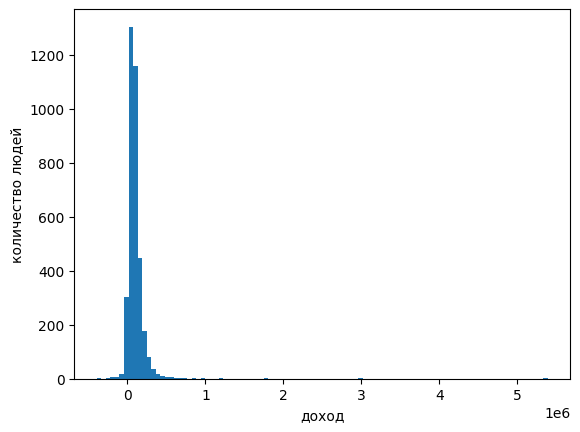

In [30]:
## визуализация
income_avid_buyers = data_avid_buyers.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) ## берем среднее значение как з/п человека
plt.hist(income_avid_buyers['monthly_income_amt'], bins=100)
plt.xlabel('доход')
plt.ylabel('количество людей')

Text(0, 0.5, 'количество людей')

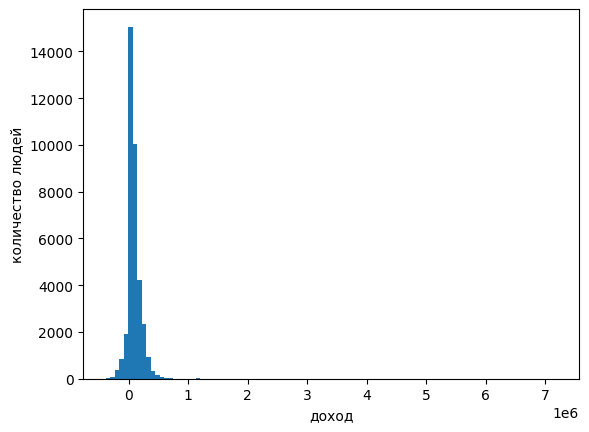

In [31]:
income_not_avid_buyers = data_not_avid_buyers.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) ## берем среднее значение 
plt.hist(income_not_avid_buyers['monthly_income_amt'], bins=100)
plt.xlabel('доход')
plt.ylabel('количество людей')

In [32]:
income_not_avid_buyers['monthly_income_amt'].mean(), income_not_avid_buyers['monthly_income_amt'].median()

(86838.79074760283, 64450.75)

In [33]:
income_avid_buyers['monthly_income_amt'].mean(), income_avid_buyers['monthly_income_amt'].median()
# по данным можно заметить, что и средний доход, и медианный доход больше у заядлых покупателей, чем у незаядлых 

(96780.40451611474, 76131.525)

#### Гипотеза 2: Заядлые покупатели оказываются из больших городов(Москва и Питер)


In [34]:
data_avid_buyers_city = data_avid_buyers.groupby('client_id', as_index=False)['city_nm']. \
    agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None) ## берем первое число если мода возвращает несколько значений
data_avid_buyers_city['city_nm'].value_counts()

city_nm
Москва             2073
Санкт-Петербург     605
Екатеринбург        182
Новосибирск         105
Самара               83
Казань               75
Краснодар            60
Нижний Новгород      55
Красноярск           54
Челябинск            53
Воронеж              50
Ростов-на-Дону       49
Волгоград            44
Пермь                38
Уфа                  35
Омск                 33
Name: count, dtype: int64

In [35]:
data_avid_big_cities = data_avid_buyers_city[(data_avid_buyers_city['city_nm'] == 'Москва') \
    | (data_avid_buyers_city['city_nm'] == 'Санкт-Петербург')]
avid_ratio = len(data_avid_big_cities) / len(data_avid_buyers_city)
avid_ratio ## примерно 75% всех заядлых покупателей живут в Москве или Питере

0.7451307735114079

In [36]:
data_not_avid_buyers_city = data_not_avid_buyers.groupby('client_id', as_index=False)['city_nm']. \
    agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None) ## берем первое число если мода возвращает несколько значений
data_not_avid_buyers_city['city_nm'].value_counts()

city_nm
Москва             15765
Санкт-Петербург     6808
Екатеринбург        2127
Новосибирск         1650
Казань              1245
Краснодар           1184
Нижний Новгород      969
Красноярск           909
Самара               865
Ростов-на-Дону       845
Воронеж              816
Челябинск            718
Пермь                706
Уфа                  664
Омск                 590
Волгоград            571
Name: count, dtype: int64

In [37]:
data_not_avid_big_cities = data_not_avid_buyers_city[(data_not_avid_buyers_city['city_nm'] == 'Москва') \
    | (data_not_avid_buyers_city['city_nm'] == 'Санкт-Петербург')]
not_avid_ratio = len(data_not_avid_big_cities) / len(data_not_avid_buyers_city)
not_avid_ratio ## примерно 62% всех не заядлых покупателей живут в Москве или Питере

0.619592665788318

#### Гипотеза 3: Заядлые покупатели чаще покупают менее популярные игры(возможно, потому что уже у них уже есть нет популярных игр, в которые модно было бы поиграть)

In [38]:
ratio_avid_buyers_not_popular = len(data_avid_buyers[data_avid_buyers['steam_popularity_score'] == 0]) / len(data_avid_buyers)
ratio_avid_buyers_not_popular

0.6992182534638363

In [39]:
ratio_not_avid_buyers_not_popular = len(data_not_avid_buyers[data_not_avid_buyers['steam_popularity_score'] == 0]) \
    / len(data_not_avid_buyers)
ratio_not_avid_buyers_not_popular 

0.6296249251483423

In [40]:
ratio_avid_buyers_not_popular / ratio_not_avid_buyers_not_popular

1.1105314061369116

#### Выводы:
>- Заядлые покупатели имеют больший доход, чем незаядлые(выборка достаточно большая, чтобы предполагать, что различия статзначимы)
>- Заядлые покупатели чаще живут в Москве или Питере (из-за больших доходов и культуры)
>- Заядлые покупатели чаще покупают непопулярные игры

### Вопрос 3: Нацелены ли игры на разные аудитории? То есть, можно ли выделить несколько групп игр, покупатели которых сильно отличаются друг от друга?

In [41]:
data_games = new_data.groupby('good_name', as_index=False).agg({'age': 'mean', 'monthly_income_amt': 'median', 'good_cnt': 'sum', 'good_price': 'mean'}). \
    rename(columns={'age': 'mean_age', 'monthly_income_amt': 'median_income_amt'}).sort_values('mean_age')
data_games.head()

,good_name,mean_age,median_income_amt,good_cnt,good_price
2763,Time Rift: Escape From Speedjail,14.0,-33460.0,1.0,259.0
2970,WRC 7 FIA World Rally Championship,14.0,121630.0,1.0,499.0
2326,Space Pilgrim Episode II: Epsilon Indi,14.0,28337.0,1.0,41.0
370,Bunker Constructor,14.0,186491.0,1.0,12.9
3105,Zero-G Gunfight,14.0,71332.0,1.0,180.0


In [42]:
data_games['good_price'].quantile(q=0.95), data_games['good_price'].quantile(q=0.05)

(1665.7764117647039, 25.969833333333334)

#### рассмотрим различия между пользователями дорогих игр (топ 5 по цене) и дешевых(топ 95% по цене)

In [43]:
exp_games = data_games[data_games['good_price'] >= data_games['good_price'].quantile(q=0.95)]

cheap_games = data_games[data_games['good_price'] <= data_games['good_price'].quantile(q=0.05)]
exp_games.head()

,good_name,mean_age,median_income_amt,good_cnt,good_price
1012,FOR HONOR - Marching Fire Edition,15.000000,294111.0,1.0,2079.000000
1802,ONE PIECE: PIRATE WARRIORS 4 - Character Pass ...,15.000000,60619.0,1.0,1799.000000
758,Destiny 2: The Witch Queen Deluxe + Bungie 30t...,17.000000,192876.5,2.0,4199.000000
887,EA SPORTS FC™ 24 - Ultimate Edition,19.466667,93368.0,15.0,10484.029333
958,Europa Universalis IV: Empire Bundle,20.000000,68000.0,1.0,2021.930000


In [44]:
exp_games_data = new_data.merge(exp_games['good_name'], on='good_name')

cheap_games_data = new_data.merge(cheap_games['good_name'], on='good_name')
exp_games_data.head()

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
0,1500606801,5-27QNYCFQL,2023-06-30,33164,1674699,Marvel’s Spider-Man: Miles Morales,2331.65,1.0,M,21,GRD,Москва,170311,0.0,False,True,False,False,Приключения
1,1500616776,5-29RA63M13,2023-07-10,28577,1674699,Marvel’s Spider-Man: Miles Morales,2456.32,1.0,M,18,SCH,Санкт-Петербург,117390,0.0,False,False,False,False,Приключения
2,1500658179,5-HOI011MV,2023-09-01,33164,1674699,Marvel’s Spider-Man: Miles Morales,2580.80,1.0,M,28,SCH,Москва,50000,0.0,False,True,False,False,Приключения
3,1500613484,5-30SEIN8NN,2023-07-06,28562,1674699,Marvel’s Spider-Man: Miles Morales,2420.16,1.0,M,15,UGR,Москва,-66172,0.0,False,False,False,False,Приключения
4,1500618046,5-2KZJ8RJ3I,2023-07-11,28577,1674699,Marvel’s Spider-Man: Miles Morales,2451.11,1.0,M,24,GRD,Волгоград,34400,0.0,False,False,False,False,Приключения


In [45]:
exp_games_clients = pd.DataFrame(exp_games_data['client_id'].unique(), columns=['client_id'])

cheap_games_clients = pd.DataFrame(cheap_games_data['client_id'].unique(), columns=['client_id'])
exp_games_clients.head()

,client_id
0,5-27QNYCFQL
1,5-29RA63M13
2,5-HOI011MV
3,5-30SEIN8NN
4,5-2KZJ8RJ3I


In [46]:
exp_games_clients_data = new_data.merge(exp_games_clients, on='client_id') ## данные людей, хоть раз купивших дорогие игры

cheap_games_clients_data = new_data.merge(cheap_games_clients, on='client_id')
exp_games_clients_data.head()

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
0,1500507284,5-1AJNLM7EN,2023-03-07,29688,890257,The Night of the Rabbit,299.0,1.0,M,45,UGR,Санкт-Петербург,350000,0.0,True,False,False,False,Приключения
1,1500529255,5-1AJNLM7EN,2023-03-31,28562,1436296,Ni no Kuni Wrath of the White Witch Remastered,1799.0,1.0,M,45,UGR,Ростов-на-Дону,350000,0.0,False,False,False,False,Приключения
2,1500493982,5-1AJNLM7EN,2023-02-25,29688,1435647,The Darkest Tales,435.0,1.0,M,45,UGR,Санкт-Петербург,350000,0.0,True,False,False,False,Приключения
3,1500510253,5-1AJNLM7EN,2023-03-07,29688,848678,RESIDENT EVIL 2 - Deluxe Edition,679.0,1.0,M,45,UGR,Москва,350000,0.0,True,False,False,False,Экшн
4,1500500686,5-1AJNLM7EN,2023-03-02,29688,890259,Deponia,24.9,1.0,M,45,UGR,Москва,350000,3258.0,True,False,False,False,Инди


In [47]:
exp_games_clients_data_income = exp_games_clients_data.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) 
## делаем группировку, чтобы зп людей не повторялись в подсчете среднего
exp_games_clients_data_income['monthly_income_amt'].mean(), exp_games_clients_data_income['monthly_income_amt'].median()

(104732.96543167353, 78014.0)

In [48]:
cheap_games_clients_data_income = cheap_games_clients_data.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) 
## делаем группировку, чтобы зп людей не повторялись в подсчете среднего
cheap_games_clients_data_income['monthly_income_amt'].mean(), cheap_games_clients_data_income['monthly_income_amt'].median()

(76358.24658801079, 60470.0)

#### Вывод: видно, чтo есть большие различия по доходам между аудиториями дорогих игр и дешевых

#### рассмотрим различия между пользователями самых продавамых игр (топ 1% по числу) и самых не продаваемых (топ 95% по числу)

In [49]:
good_sell = data_games[data_games['good_cnt'] >= data_games['good_cnt'].quantile(q=0.99)]
bad_sell = data_games[data_games['good_cnt'] <= data_games['good_cnt'].quantile(q=0.05)]
good_sell

,good_name,mean_age,median_income_amt,good_cnt,good_price
2803,Townscaper,21.409091,62000.0,462.0,127.251515
709,Dead Cells,21.502423,53600.0,1238.0,352.464095
40,APEX LEGENDS - 1000 COINS VIRTUAL CURRENCY,21.866279,56000.0,344.0,1031.623430
2928,VCB: Why City 4k,22.920283,58318.0,991.0,27.880666
1780,Noise,23.074534,54494.0,1127.0,13.126167
632,Cyberline Racing,23.456897,50000.0,348.0,14.554167
1268,Hitman: Absolution,23.504132,56000.0,363.0,91.396281
2104,Resident Evil 7,23.682996,62000.0,3511.0,348.509507
130,Apex Legends: 2150 Coins,23.955752,62000.0,339.0,1499.000000
2359,Squad,24.035390,65834.5,1102.0,1006.514492


In [50]:
good_sell_clients = new_data.merge(good_sell, on='good_name')
bad_sell_clients = new_data.merge(bad_sell, on='good_name')
good_sell_clients

,id,client_id,order_day,category_id,good_id,good_name,good_price_x,good_cnt_x,gender_cd,age,...,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name,mean_age,median_income_amt,good_cnt_y,good_price_y
0,1500288143,5-1QCUV9SY7,2022-07-03,28577,1314503,Neon White,550.0,1.0,M,38,...,1676.0,False,False,False,False,Инди,26.450402,62148.0,373.0,549.537534
1,1500284094,5-2ENPQUQY6,2022-06-28,28568,1314503,Neon White,550.0,1.0,M,32,...,1676.0,False,False,False,False,Инди,26.450402,62148.0,373.0,549.537534
2,1500281196,5-1ECSEPTXH,2022-06-24,28562,1314503,Neon White,550.0,1.0,F,29,...,1676.0,False,False,False,False,Инди,26.450402,62148.0,373.0,549.537534
3,1500281962,5-XIJOIVOC,2022-06-26,28568,1314503,Neon White,550.0,1.0,M,35,...,1676.0,False,False,False,False,Инди,26.450402,62148.0,373.0,549.537534
4,1500282267,5-30T575I3C,2022-06-26,28577,1314503,Neon White,550.0,1.0,M,36,...,1676.0,False,False,False,False,Инди,26.450402,62148.0,373.0,549.537534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24246,1500479898,5-1DDCM4JA3,2023-02-14,28579,880568,Cyberline Racing,5.8,1.0,M,24,...,2444.0,False,False,False,False,Гонки,23.456897,50000.0,348.0,14.554167
24247,1500485482,5-3EIYYDILG,2023-02-19,28579,880568,Cyberline Racing,5.8,1.0,M,28,...,2444.0,False,False,False,False,Гонки,23.456897,50000.0,348.0,14.554167
24248,1500544031,5-39F9SR1J3,2023-04-17,28579,880568,Cyberline Racing,5.8,1.0,M,19,...,2444.0,False,False,False,False,Гонки,23.456897,50000.0,348.0,14.554167
24249,1500525851,5-VAPT0BRT,2023-03-26,28579,880568,Cyberline Racing,5.8,1.0,M,37,...,2444.0,False,False,False,False,Гонки,23.456897,50000.0,348.0,14.554167


In [51]:
good_sell_clients_gr = good_sell_clients.groupby(by='client_id').agg({'age': 'mean', 'monthly_income_amt': 'mean'})
good_sell_clients_gr['age'].mean(), good_sell_clients_gr['monthly_income_amt'].mean() 

(25.157943316320992, 83198.86958102061)

In [52]:
bad_sell_clients_gr = bad_sell_clients.groupby(by='client_id').agg({'age': 'mean', 'monthly_income_amt': 'mean'})
bad_sell_clients_gr['age'].mean(), bad_sell_clients_gr['monthly_income_amt'].mean() 

(29.340807174887892, 96549.32156203288)

#### Вывод: менее популярные игры имеют разную аудиторию относительно популярных игр

#### рассмотрим людей, которые много покупают по скидкам(в категории скидок)
>- Тогда попробуем разделить выборку на пользователей, которые чаще всего покупают игры по скидкам, и покупателей, ни разу не покупавшим по скидкам.
>- Есть предположение, что люди, которые часто покупают по скидкам, имеют меньший доход

In [53]:
discount = new_data[new_data['is_discount']]
discount_clients = pd.DataFrame(discount['client_id'].unique(), columns=['client_id'])
discount_clients ## люди, хоть раз купившие что то по скидке

,client_id
0,5-25R6ZT3L9
1,5-1AJNLM7EN
2,5-2OVDOM6MV
3,5-2TSXAZV3P
4,5-1RQXX2A5T
...,...
6021,5-30B6Q92NL
6022,5-28KNZUVN5
6023,5-2J3YH6LDI
6024,5-EVJ5Z7NW


In [54]:
discount_clients_data = new_data.merge(discount_clients, on='client_id') 
discount_means = discount_clients_data.groupby(by='client_id', as_index=False).agg({'is_discount': 'mean'})
discount_means ## доля покупок со скидкой у людей

,client_id,is_discount
0,1-1IVY7MI,0.500000
1,1-1JLNQNT,0.100000
2,1-1M5G4O,0.500000
3,1-1MJ8I6O,1.000000
4,1-1MSCJAX,0.222222
...,...,...
6021,7-3KRLRTDZA,0.500000
6022,7-3KUZCV7GU,0.500000
6023,7-3L0FAMGCO,0.500000
6024,7-3L6AS4S7E,1.000000


In [55]:
## людьми которые много покупают по скидкам будем считать тех, кто более половины покупок совершил по скидкам
big_discounters = discount_means[discount_means['is_discount'] >= 0.5]
big_discounters_data = new_data.merge(big_discounters['client_id'], on='client_id')
big_discounters_data

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
0,1500643713,5-ZFSDPGT6,2023-08-12,28568,890257,The Night of the Rabbit,29.90,1.0,F,30,SCH,Москва,266328,0.0,False,False,False,False,Приключения
1,1500643735,5-ZFSDPGT6,2023-08-12,29688,890134,Edna & Harvey: The Breakout - Anniversary Edition,74.25,1.0,F,30,GRD,Москва,103768,0.0,True,False,False,False,Инди
2,1500643374,5-2B98C0R24,2023-08-12,28562,890257,The Night of the Rabbit,29.90,1.0,F,21,SCH,Омск,26000,0.0,False,False,False,False,Приключения
3,1500643368,5-2B98C0R24,2023-08-12,29688,890137,The Franz Kafka Videogame,29.90,1.0,F,21,SCH,Екатеринбург,26000,0.0,True,False,False,False,Приключения
4,1500636730,5-3FEIOCEFO,2023-08-05,29688,890257,The Night of the Rabbit,29.90,1.0,M,18,SCH,Екатеринбург,21253,0.0,True,False,False,False,Приключения
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5614,1500220581,5-NQNW5CV1,2022-03-03,29688,848530,MASS EFFECT: LEGENDARY EDITION,1399.60,1.0,M,28,GRD,Санкт-Петербург,110000,0.0,True,False,False,False,Без Категории
5615,1500225440,5-1AZL1PFP4,2022-03-10,29688,1123748,The Survivalists - Deluxe Edition,219.75,1.0,M,24,SCH,Москва,74000,0.0,True,False,False,False,Экшн
5616,1500293081,5-28KNZUVN5,2022-07-09,29688,1332226,Blacksad: Under the Skin,1199.00,1.0,M,25,GRD,Воронеж,158000,0.0,True,False,False,False,Без Категории
5617,1500296301,5-EVJ5Z7NW,2022-07-15,29688,1123807,Train Simulator: LGV: Marseille - Avignon Rout...,239.60,1.0,M,56,GRD,Екатеринбург,134000,0.0,True,False,False,False,Без Категории


In [56]:
discounters_data_merged = new_data.merge(discount_clients, on='client_id', how='outer', indicator=True)
no_discounters_data = discounters_data_merged[discounters_data_merged['_merge'] == 'left_only'] ## данные людей, не покупавших игр в категории скидок

no_discounters_data.head()

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name,_merge
145,1500346354,5-30HUWQZ60,2022-09-26,28562,890257,The Night of the Rabbit,29.90,1.0,F,26,UGR,Москва,26000,0.0,False,False,False,False,Приключения,left_only
182,1500232484,5-VIJH1N3P,2022-04-01,28562,890257,The Night of the Rabbit,33.49,1.0,M,26,UGR,Москва,26000,0.0,False,False,False,False,Приключения,left_only
317,1500409295,5-25NWB628K,2022-12-07,28562,890257,The Night of the Rabbit,29.90,1.0,M,32,GRD,Санкт-Петербург,38000,0.0,False,False,False,False,Приключения,left_only
324,1500378273,5-YRDIIKX6,2022-11-08,28568,890257,The Night of the Rabbit,29.90,1.0,F,27,SCH,Казань,35000,0.0,False,False,False,False,Приключения,left_only
325,1500747910,5-3DVGWRIV5,2023-10-27,28562,890257,The Night of the Rabbit,29.90,1.0,M,20,GRD,Москва,8000,0.0,False,False,False,False,Приключения,left_only


In [57]:
big_discounters_data['monthly_income_amt'].mean(), big_discounters_data['monthly_income_amt'].median()

(84535.75689624489, 62000.0)

In [58]:
no_discounters_data['monthly_income_amt'].mean(), no_discounters_data['monthly_income_amt'].median()

(90935.13935003521, 66919.0)

##### видно, что действительно есть небольшие различия между покупателями игр, со скидками и без

### Вопрос 4: Справедливы ли выводы предыдущих пунктов на всем представленном временном промежутке?

#### Попробуем разделить датасет на два года - 2022 и 2023 и сравнить результаты

In [59]:
new_data_22 = new_data[new_data['order_day'].dt.year == 2022]
new_data_23 = new_data[new_data['order_day'].dt.year == 2023]

In [60]:
## сделаем группировку по пользователям
group_buyers_22 = new_data_22.groupby(by=['client_id', 'gender_cd'], as_index=False).agg({'age': 'mean', 'good_price': 'sum', 'good_cnt': 'sum', 'monthly_income_amt': 'mean'}) \
    .rename(columns={'good_price': 'sum_buy', 'good_cnt': 'sum_count'}) 
group_buyers_23 = new_data_23.groupby(by=['client_id', 'gender_cd'], as_index=False).agg({'age': 'mean', 'good_price': 'sum', 'good_cnt': 'sum', 'monthly_income_amt': 'mean'}) \
    .rename(columns={'good_price': 'sum_buy', 'good_cnt': 'sum_count'}) 
group_buyers_22

,client_id,gender_cd,age,sum_buy,sum_count,monthly_income_amt
0,1-14HPC7Z,M,42.0,29.00,1.0,386000.0
1,1-15GSF3N,M,36.0,133.00,1.0,16400.0
2,1-17GCAKP,M,48.0,7.25,1.0,62000.0
3,1-1AJFCHX,M,36.0,6574.01,12.0,230000.0
4,1-1BFARRI,M,39.0,1454.88,1.0,290000.0
...,...,...,...,...,...,...
20874,5-ZYTUU9V2,M,40.0,899.00,1.0,171270.0
20875,5-ZYZYZFAU,M,27.0,2098.01,2.0,57812.5
20876,5-ZZ66LNDQ,M,20.0,401.47,6.0,20000.0
20877,5-ZZIBS7GY,M,36.0,480.00,1.0,115595.0


In [61]:
group_buyers_22['gender_cd'].value_counts() 

gender_cd
M    18455
F     2424
Name: count, dtype: int64

In [62]:
group_buyers_23['gender_cd'].value_counts() 

gender_cd
M    20490
F     2434
Name: count, dtype: int64

In [63]:
group_buyers_22['age'].mean() ## не сильно отличается от результатов ответа на первый вопрос

26.963425770710604

In [64]:
group_buyers_23['age'].mean() ## не сильно отличается от результатов ответа на первый вопрос

25.68676205432443

In [65]:
group_buyers_22['monthly_income_amt'].mean() ## не сильно отличается от результатов ответа на первый вопрос

90833.86323993614

In [66]:
group_buyers_23['monthly_income_amt'].mean() ## не сильно отличается от результатов ответа на первый вопрос

85186.05245297136

#### Итог: выводы первого вопроса справедливы на всем представленном временном промежутке, средний возраст и доход за 22 и 23 года мало различаются.

In [67]:
data_avid_2022 = data_avid_buyers[data_avid_buyers['order_day'].dt.year == 2022]
data_avid_2023 = data_avid_buyers[data_avid_buyers['order_day'].dt.year == 2023]

In [68]:
data_not_avid_2022 = data_not_avid_buyers[data_not_avid_buyers['order_day'].dt.year == 2022]
data_not_avid_2023 = data_not_avid_buyers[data_not_avid_buyers['order_day'].dt.year == 2023]

In [69]:
data_avid_2022_inc = data_avid_2022.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'})
data_avid_2022_inc['monthly_income_amt'].mean()

98799.70167293673

In [70]:
data_not_avid_2022_inc = data_not_avid_2022.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'})
data_not_avid_2022_inc['monthly_income_amt'].mean()

89850.41972785456

In [71]:
data_avid_2023_inc = data_avid_2023.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'})
data_avid_2023_inc['monthly_income_amt'].mean() 

94640.10245198531

In [72]:
data_not_avid_2023_inc = data_not_avid_2023.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'})
data_not_avid_2023_inc['monthly_income_amt'].mean() ## мало отличается

83864.06676708326

#### Итог: выводы второго вопроса справедливы на всем представленном временном промежутке, за 2022 и 2023 года есть разница в доходах примерно на 10000

In [73]:
exp_games_clients_data_22 = exp_games_clients_data[exp_games_clients_data['order_day'].dt.year == 2022]
exp_games_clients_data_23 = exp_games_clients_data[exp_games_clients_data['order_day'].dt.year == 2023]
exp_games_clients_data_income_22 = exp_games_clients_data_22.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) 
## делаем группировку, чтобы зп людей не повторялись в подсчете среднего
exp_games_clients_data_income_22['monthly_income_amt'].mean(), exp_games_clients_data_income_22['monthly_income_amt'].median()

(108950.9277759845, 80991.28571428571)

In [74]:
cheap_games_clients_data_22 = cheap_games_clients_data[exp_games_clients_data['order_day'].dt.year == 2022]
cheap_games_clients_data_23 = cheap_games_clients_data[exp_games_clients_data['order_day'].dt.year == 2023]
cheap_games_clients_data_income_22 = cheap_games_clients_data_22.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) 
## делаем группировку, чтобы зп людей не повторялись в подсчете среднего
cheap_games_clients_data_income_22['monthly_income_amt'].mean(), cheap_games_clients_data_income_22['monthly_income_amt'].median()

(80024.3479813601, 59666.666666666664)

In [75]:
exp_games_clients_data_income_23 = exp_games_clients_data_23.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) 
## делаем группировку, чтобы зп людей не повторялись в подсчете среднего
exp_games_clients_data_income_23['monthly_income_amt'].mean(), exp_games_clients_data_income_23['monthly_income_amt'].median()

(100419.84649725808, 74863.5)

In [76]:
cheap_games_clients_data_income_23 = cheap_games_clients_data_23.groupby(by='client_id', as_index=False).agg({'monthly_income_amt': 'mean'}) 
## делаем группировку, чтобы зп людей не повторялись в подсчете среднего
cheap_games_clients_data_income_23['monthly_income_amt'].mean(), cheap_games_clients_data_income_23['monthly_income_amt'].median()

(76172.78039422442, 61904.0)

#### Выводы третьего вопроса справедливы на всем временном промежутке, разница за годы - более 20% в среднем и медианном доходах

## Задача 2

### Вопрос 1: Исследование текущих схем выставления цены и их эффективности

#### Рассмотрим игры, оказавшиеся в категории скидок

In [77]:
have_discount = new_data[new_data['is_discount']]
have_discount_games = pd.DataFrame(have_discount['good_name'].unique(), columns=['good_name'])
have_discount_games_data = new_data.merge(have_discount_games, on='good_name') ## данные об играх, где хоть раз были скидки

have_discount_games_data

,id,client_id,order_day,category_id,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,is_discount,is_bestseller,is_new,is_preorder,true_category_name
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,True,False,False,False,Приключения
1,1500235761,5-20N8J58AG,2022-04-04,28568,890257,The Night of the Rabbit,33.49,1.0,M,35,UGR,Нижний Новгород,-60322,0.0,False,False,False,False,Приключения
2,1500507284,5-1AJNLM7EN,2023-03-07,29688,890257,The Night of the Rabbit,299.00,1.0,M,45,UGR,Санкт-Петербург,350000,0.0,True,False,False,False,Приключения
3,1500316482,5-2OVDOM6MV,2022-08-19,29688,890257,The Night of the Rabbit,29.90,1.0,M,25,GRD,Екатеринбург,56000,0.0,True,False,False,False,Приключения
4,1500382862,5-14EM5B07K,2022-11-13,28568,890257,The Night of the Rabbit,29.90,1.0,M,34,GRD,Ростов-на-Дону,242000,0.0,False,False,False,False,Приключения
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28347,1500252617,5-2RM0FG42L,2022-05-04,29688,1124119,Train Sim World,143.70,1.0,M,22,SCH,Челябинск,32000,0.0,True,False,False,False,Без Категории
28348,1500296361,5-1CN1NJ4P6,2022-07-15,29688,1124307,Train Simulator: West Somerset Railway Route A...,125.70,1.0,M,30,PGR,Санкт-Петербург,9616,0.0,True,False,False,False,Без Категории
28349,1500222514,5-2J3YH6LDI,2022-03-06,29688,848113,Narcos: Rise of the Cartels,103.00,1.0,M,30,GRD,Санкт-Петербург,50000,0.0,True,False,False,False,Без Категории
28350,1500296301,5-EVJ5Z7NW,2022-07-15,29688,1123807,Train Simulator: LGV: Marseille - Avignon Rout...,239.60,1.0,M,56,GRD,Екатеринбург,134000,0.0,True,False,False,False,Без Категории


In [78]:
mean_with_discount = have_discount_games_data[have_discount_games_data['is_discount']]['good_price'].mean()
mean_with_discount

501.6752414248021

In [79]:
mean_without_discount = have_discount_games_data[have_discount_games_data['is_discount'] == False]['good_price'].mean()
mean_without_discount ## сразу можем заметить, что при скидках средняя цена игр падает на 2

609.2273199499326

In [80]:
100 - (mean_with_discount / mean_without_discount) * 100 ## сразу можем заметить, что при скидках средняя цена игр падает примерно на 18%

17.65385021373784

In [81]:
## действительно, происходит снижение цен 

#### Проверим, действительно ли нахождение игры в топе позволяет ставить большие цены

In [82]:
top_100 = new_data[(new_data['steam_popularity_score'] > 0) & (new_data['steam_popularity_score'] <= 100)]
top_1000 = new_data[(new_data['steam_popularity_score'] > 100) & (new_data['steam_popularity_score'] <= 1000)]
top_5000 = new_data[(new_data['steam_popularity_score'] > 1000) & (new_data['steam_popularity_score'] <= 5000)]
no_rating = new_data[(new_data['steam_popularity_score'] == 0)]

In [83]:
top_100['good_price'].mean()

1430.1845479868318

In [84]:
top_1000['good_price'].mean()

757.3037099424815

In [85]:
top_5000['good_price'].mean()

319.7342879988369

In [86]:
no_rating['good_price'].mean() 

561.5165542053932

#### Вывод: действительно, для игр с рейтингом до 5000 нахождение игры выше в топе позволяет ставить большие цены, для безрейтинговых игр данное условие не выполняется(возможно, что потребители этих игр другие, т.е не смотрят на рейтинг)

#### выделим игры, которые сильно(больше 100%) меняют цены, которые вообще не меняют цены, и которые делают изменения от 0 до 100% 
>- Логично, что мало что можно сказать про спрос игр, которые не меняют цены.
>- Будем рассматривать ценообразование оставшихся двух типов игр 

In [87]:
max_prices = new_data.groupby(by='good_name', as_index=False).agg({'good_price': 'max'}).rename(columns={'good_price': 'max_price'})
min_prices = new_data.groupby(by='good_name', as_index=False).agg({'good_price': 'min'}).rename(columns={'good_price': 'min_price'})

prices_data = max_prices.merge(min_prices, on='good_name')
prices_data

,good_name,max_price,min_price
0,//N.P.P.D. RUSH// - The milk of Ultraviolet,14.95,13.35
1,//SNOWFLAKE TATTOO//,19.35,19.35
2,11-11 Memories Retold,149.85,149.85
3,112 Operator,465.00,93.00
4,15 Days,59.80,30.00
...,...,...,...
3122,Подписка Xbox LIVE GOLD на 3 месяца,2099.00,1709.05
3123,Пополнение кошелька Playstation Store Польша 1...,3299.00,3299.00
3124,Пополнение кошелька Playstation Store Польша 1...,599.00,599.00
3125,Пополнение кошелька Playstation Store Польша 5...,1749.00,1749.00


In [88]:
no_change_prices = prices_data[prices_data['max_price'] == prices_data['min_price']] ## игры, которые не меняют цены
no_change_prices_data = new_data.merge(no_change_prices, on='good_name')
no_change_prices
## странно, что больше 1/3 всех товаров не меняли цены

,good_name,max_price,min_price
1,//SNOWFLAKE TATTOO//,19.35,19.35
2,11-11 Memories Retold,149.85,149.85
8,3SwitcheD,19.90,19.90
12,9 Monkeys of Shaolin,149.70,149.70
15,A Blind Legend,43.80,43.80
...,...,...,...
3120,Карта оплаты Xbox Game Pass на 3 месяца,2208.00,2208.00
3123,Пополнение кошелька Playstation Store Польша 1...,3299.00,3299.00
3124,Пополнение кошелька Playstation Store Польша 1...,599.00,599.00
3125,Пополнение кошелька Playstation Store Польша 5...,1749.00,1749.00


In [89]:
big_change_prices = prices_data[prices_data['max_price'] >=  2 * prices_data['min_price']] ## игры, которые сильно меняют цены
big_change_prices_data = new_data.merge(big_change_prices, on='good_name') ## все данные игр, сильно меняющих цены
big_change_prices ## видим, что таких игр довольно много

,good_name,max_price,min_price
3,112 Operator,465.0,93.00
5,16bit Trader,79.0,6.32
10,7'scarlet,515.0,128.75
11,8infinity,29.0,2.32
14,911 Operator,349.0,69.80
...,...,...,...
3088,Wreckfest - Season Pass 2,649.0,324.50
3091,X-Blades,199.0,19.90
3103,Zanzarah: The Hidden Portal,249.0,24.90
3104,Zarya - 1: Mystery on the Moon,149.0,29.80


In [90]:
avg_change_prices = prices_data[(prices_data['max_price'] <  2 * prices_data['min_price']) \
    & (prices_data['max_price'] !=  prices_data['min_price'])] ## игры, которые сильно меняют цены
avg_change_prices_data = new_data.merge(avg_change_prices, on='good_name') ## все данные этих игр
avg_change_prices 

,good_name,max_price,min_price
0,//N.P.P.D. RUSH// - The milk of Ultraviolet,14.95,13.35
4,15 Days,59.80,30.00
6,1943 Deadly Desert,51.80,26.00
7,1954 Alcatraz,27.89,24.90
9,4th Generation Warfare,699.00,419.40
...,...,...,...
3116,looK INside - Chapter 2,249.00,174.30
3118,Карта оплаты Xbox Game Pass Ultimate на 1 месяц,1099.00,882.55
3119,Карта оплаты Xbox Game Pass Ultimate на 3 месяца,3099.00,2279.05
3121,Подписка Xbox LIVE GOLD на 12 месяцев,5110.00,3989.05


#### Проверим гипотезу, что большое изменение цен действительно помогает достичь эффективности 
>- Сравним среднюю выручку за день big_change_prices и no_change_prices

In [91]:
big_change_prices_rev = big_change_prices_data.groupby(by='order_day', as_index=False).agg({'good_name': 'nunique', 'good_price': 'sum'}).\
    rename(columns={'good_name': 'games_count', 'good_price': 'day_revenue'})
big_change_prices_rev['mean_rev'] = big_change_prices_rev['day_revenue'] / big_change_prices_rev['games_count']
big_change_prices_rev

,order_day,games_count,day_revenue,mean_rev
0,2022-02-07,2,359.47,179.735000
1,2022-02-08,8,1118.20,139.775000
2,2022-02-09,5,1189.10,237.820000
3,2022-02-14,1,14.90,14.900000
4,2022-02-15,2,109.85,54.925000
...,...,...,...,...
619,2023-10-25,30,22104.57,736.819000
620,2023-10-26,41,24295.96,592.584390
621,2023-10-27,39,33756.88,865.561026
622,2023-10-28,53,44373.07,837.227736


In [92]:
big_change_prices_rev = big_change_prices_data.groupby(by='order_day', as_index=False).agg({'good_name': 'nunique', 'good_price': 'sum'}).\
    rename(columns={'good_name': 'games_count', 'good_price': 'day_revenue'})
big_change_prices_rev['mean_rev'] = big_change_prices_rev['day_revenue'] / big_change_prices_rev['games_count']
big_change_prices_rev

,order_day,games_count,day_revenue,mean_rev
0,2022-02-07,2,359.47,179.735000
1,2022-02-08,8,1118.20,139.775000
2,2022-02-09,5,1189.10,237.820000
3,2022-02-14,1,14.90,14.900000
4,2022-02-15,2,109.85,54.925000
...,...,...,...,...
619,2023-10-25,30,22104.57,736.819000
620,2023-10-26,41,24295.96,592.584390
621,2023-10-27,39,33756.88,865.561026
622,2023-10-28,53,44373.07,837.227736


In [93]:
no_change_prices_rev = no_change_prices_data.groupby(by='order_day', as_index=False).agg({'good_name': 'nunique', 'good_price': 'sum'}).\
    rename(columns={'good_name': 'games_count', 'good_price': 'day_revenue'})
no_change_prices_rev['mean_rev'] = no_change_prices_rev['day_revenue'] / no_change_prices_rev['games_count']
no_change_prices_rev

,order_day,games_count,day_revenue,mean_rev
0,2022-02-07,2,34.70,17.350000
1,2022-02-08,4,549.10,137.275000
2,2022-02-09,6,2129.00,354.833333
3,2022-02-11,2,744.30,372.150000
4,2022-02-13,1,128.75,128.750000
...,...,...,...,...
614,2023-10-25,11,29223.50,2656.681818
615,2023-10-26,8,17705.40,2213.175000
616,2023-10-27,23,20606.98,895.955652
617,2023-10-28,19,55744.47,2933.919474


In [94]:
two_datas = no_change_prices_rev.merge(big_change_prices_rev, on='order_day', how='outer')
(two_datas['mean_rev_y'] > two_datas['mean_rev_x']).mean()

0.5907643312101911

#### Вывод: в 59% дней игры, которые сильно меняют цены, получают большую дневную выручку, чем игры, которые не меняют цены

### Вопрос 2: Изучение ограничений, при которых можно моделировать эластичность
>- Рассмотрим предложение фирм, представляющих игры
>- Оно должно быть достаточно стабильным и не зависящим от сезонности, фирма готова продать любое количество игр в любое время
>- Значит, предложением фирм можно пренебречь, и рассматривать только спрос(т.к любая точка - пересечение спроса и предложения) 

### Вопрос 3: Предварительное построение эластичности
>- Из микроэкономики знаем, что эластичность $E_d = \frac{dQ/Q}{dP/P} = \frac{dQ}{dP} \cdot \frac{P}{Q}$

In [95]:
big_change_time_grouped = big_change_prices_data.groupby(by='order_day', as_index=False).agg({'good_cnt': 'sum', 'good_price': 'mean'}).\
    rename(columns={'good_price': 'mean_price'})
## суммарное кол-во заказов в день и средние цены
big_change_time_grouped

,order_day,good_cnt,mean_price
0,2022-02-07,3.0,119.823333
1,2022-02-08,9.0,124.244444
2,2022-02-09,5.0,237.820000
3,2022-02-14,1.0,14.900000
4,2022-02-15,2.0,54.925000
...,...,...,...
619,2023-10-25,53.0,417.067358
620,2023-10-26,64.0,379.624375
621,2023-10-27,78.0,432.780513
622,2023-10-28,105.0,422.600667


In [96]:
avg_change_time_grouped = avg_change_prices_data.groupby(by='order_day', as_index=False).agg({'good_cnt': 'sum', 'good_price': 'mean'}).\
    rename(columns={'good_price': 'mean_price'})
## суммарное кол-во заказов в день и средние цены
avg_change_time_grouped

,order_day,good_cnt,mean_price
0,2022-02-08,1.0,133.000000
1,2022-02-09,3.0,341.566667
2,2022-02-14,7.0,22.185714
3,2022-02-17,2.0,11.880000
4,2022-02-18,2.0,36.440000
...,...,...,...
613,2023-10-25,44.0,1611.847045
614,2023-10-26,53.0,1995.177170
615,2023-10-27,59.0,1703.355254
616,2023-10-28,82.0,1301.275610


In [97]:
## используем готовое решение
x_1 = big_change_time_grouped['mean_price']
x_1 = sm.add_constant(x_1)
y_1 = big_change_time_grouped['good_cnt']

ols = sm.OLS(y_1,x_1).fit()
ols.summary() ## коэф при mean_price - -0.0504(эластичность спроса)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               good_cnt   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.428
Date:                Fri, 25 Apr 2025   Prob (F-statistic):             0.0201
Time:                        20:05:13   Log-Likelihood:                -3426.6
No. Observations:                 624   AIC:                             6857.
Df Residuals:                     622   BIC:                             6866.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        110.3968      8.589     12.853      0.000      93.529     127.264
mean_price    -0.0504      0.022     -2.330      0.020      -0.093      -0.008
==============================================================================
Omnibus:                      357.282   Durbin-Watson:                   0.370
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3733.744
Skew:                           2.361   Prob(JB):                         0.00
Kurtosis:                      14.014   Cond. No.                     1.45e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.45e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [98]:
## используем готовое решение
x_2 = avg_change_time_grouped['mean_price']
x_2 = sm.add_constant(x_2)
y_2 = avg_change_time_grouped['good_cnt']

ols = sm.OLS(y_2,x_2).fit()
ols.summary() ## коэф при mean_price - 0.0091

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               good_cnt   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     40.49
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           3.86e-10
Time:                        20:05:13   Log-Likelihood:                -2701.4
No. Observations:                 618   AIC:                             5407.
Df Residuals:                     616   BIC:                             5416.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.7926      1.648     15.047      0.000      21.557      28.028
mean_price     0.0091      0.001      6.363      0.000       0.006       0.012
==============================================================================
Omnibus:                      363.008   Durbin-Watson:                   0.691
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4532.236
Skew:                           2.369   Prob(JB):                         0.00
Kurtosis:                      15.392   Cond. No.                     2.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### видим проблемы - коэффициент при p = 0.0091 > 0, т.е не выполняется закон спроса
>- При увеличении цены покупают больше, так быть не должно

Text(0.5, 0, 'время')

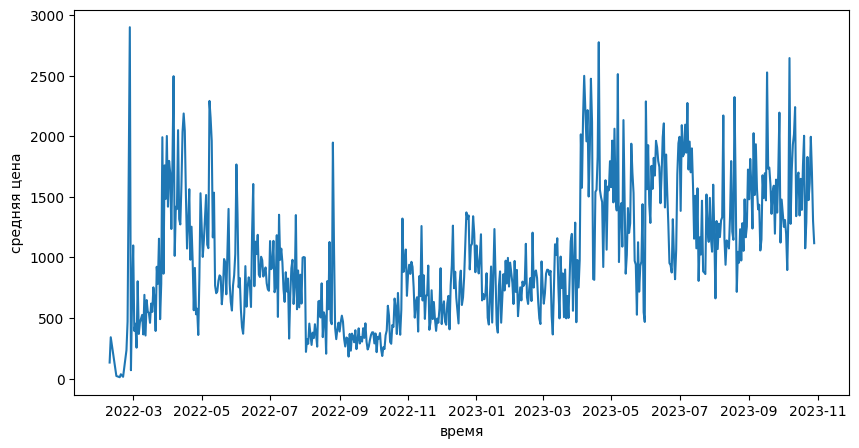

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(avg_change_time_grouped['order_day'], avg_change_time_grouped['mean_price'])
plt.ylabel('средняя цена')
plt.xlabel('время') ## видно, что есть возрастающий тренд 

Text(0.5, 0, 'время')

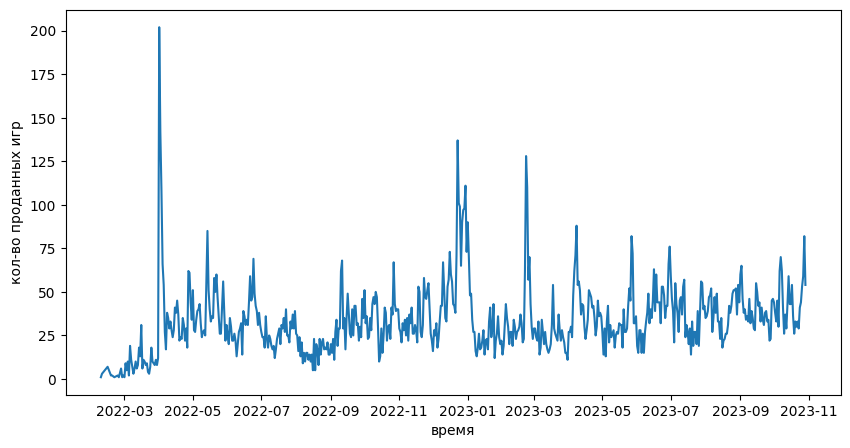

In [100]:
plt.figure(figsize=(10, 5))
plt.plot(avg_change_time_grouped['order_day'], avg_change_time_grouped['good_cnt'])
plt.ylabel('кол-во проданных игр')
plt.xlabel('время') ## видно, что есть возрастающий тренд 

### Вопрос 4: Выявление факторов помимо цены, которые могут повлиять на результаты предыдущего пункта
>- В данных есть тренд по кол-ву проданных товаров(люди постепенно начинают пользоваться нашим сервисом, приходят новые)
>- Нет точных данных по пользованию сервисом, будем довольствоваться данными роста клиентов T-Банка(считаем, что рост сервиса город пропорционален росту числа клиентов Т-Банка)
>- За 2023 год число клиентов выросло на 28%, в 2022 - на 39% (взял с отчета Т-Банка)
>- На цены действует тренд по инфляции - за 2022 год в России 12 %, за 2023 - 7.4 %
>- Решением данной проблемы будет избавление данных от тренда


### Вопрос 5: Оценка влияния этих факторов и избавление от них
>- Данные факторы могут влиять на данные и исказить модель, исказив величину спроса без тренда на 78%, а цену на 20% 

In [101]:
## для простоты, будем считать, что изменения тренда good_cnt линейны
## уберем тренд
big_change_time_grouped['day'] = big_change_time_grouped['order_day'].dt.dayofyear
big_change_time_grouped['year'] = big_change_time_grouped['order_day'].dt.year
## за 2022 год
mask1 = big_change_time_grouped['year'] == 2022
## уберем тренд кол-ва товаров
big_change_time_grouped.loc[mask1, 'good_cnt'] = (big_change_time_grouped.loc[mask1, 'good_cnt'] -
    (0.39 * big_change_time_grouped.loc[mask1, 'day'] * big_change_time_grouped.loc[mask1, 'good_cnt'] / 365)
)
## уберем тренд кол-ва инфляции
big_change_time_grouped.loc[mask1, 'mean_price'] = (big_change_time_grouped.loc[mask1, 'mean_price'] -
    (0.12 * big_change_time_grouped.loc[mask1, 'day'] * big_change_time_grouped.loc[mask1, 'mean_price'] / 365)
)

mask2 = big_change_time_grouped['year'] == 2023
## уберем тренд кол-ва товаров

big_change_time_grouped.loc[mask2, 'good_cnt'] -= big_change_time_grouped.loc[mask2, 'good_cnt'] * 0.39
big_change_time_grouped.loc[mask2, 'good_cnt'] = (big_change_time_grouped.loc[mask2, 'good_cnt'] -
    (0.28 * big_change_time_grouped.loc[mask2, 'day'] * big_change_time_grouped.loc[mask2, 'good_cnt'] / 365)
)
## уберем тренд кол-ва инфляции
big_change_time_grouped.loc[mask2, 'mean_price'] -= big_change_time_grouped.loc[mask2, 'mean_price'] * 0.12
big_change_time_grouped.loc[mask2, 'mean_price'] = (big_change_time_grouped.loc[mask2, 'mean_price'] -
    (0.074 * big_change_time_grouped.loc[mask2, 'day'] * big_change_time_grouped.loc[mask2, 'mean_price'] / 365)
)

big_change_time_grouped

,order_day,good_cnt,mean_price,day,year
0,2022-02-07,2.878192,118.326362,38,2022
1,2022-02-08,8.624959,122.651392,39,2022
2,2022-02-09,4.786301,234.692504,40,2022
3,2022-02-14,0.951918,14.679562,45,2022
4,2022-02-15,1.901699,54.094353,46,2022
...,...,...,...,...,...
619,2023-10-25,24.939273,344.845278,298,2023
620,2023-10-26,30.085401,313.818435,299,2023
621,2023-10-27,36.630082,357.683015,300,2023
622,2023-10-28,49.260592,349.194213,301,2023


Text(0, 0.5, 'средняя цена игр')

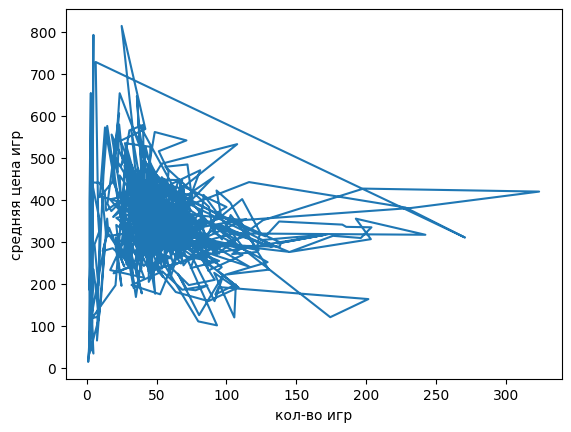

In [102]:
plt.plot(big_change_time_grouped['good_cnt'], big_change_time_grouped['mean_price'])
plt.xlabel('кол-во игр')
plt.ylabel('средняя цена игр')

In [103]:
## для простоты, будем считать, что изменения тренда good_cnt линейны
## уберем тренд
avg_change_time_grouped['day'] = avg_change_time_grouped['order_day'].dt.dayofyear
avg_change_time_grouped['year'] = avg_change_time_grouped['order_day'].dt.year
## за 2022 год
mask1 = avg_change_time_grouped['year'] == 2022
## уберем тренд кол-ва товаров
avg_change_time_grouped.loc[mask1, 'good_cnt'] = (avg_change_time_grouped.loc[mask1, 'good_cnt'] -
    (0.39 * avg_change_time_grouped.loc[mask1, 'day'] * avg_change_time_grouped.loc[mask1, 'good_cnt'] / 365)
)
## уберем тренд кол-ва инфляции
avg_change_time_grouped.loc[mask1, 'mean_price'] = (avg_change_time_grouped.loc[mask1, 'mean_price'] -
    (0.12 * avg_change_time_grouped.loc[mask1, 'day'] * avg_change_time_grouped.loc[mask1, 'mean_price'] / 365)
)

mask2 = avg_change_time_grouped['year'] == 2023
## уберем тренд кол-ва товаров

avg_change_time_grouped.loc[mask2, 'good_cnt'] -= avg_change_time_grouped.loc[mask2, 'good_cnt'] * 0.39
avg_change_time_grouped.loc[mask2, 'good_cnt'] = (avg_change_time_grouped.loc[mask2, 'good_cnt'] -
    (0.28 * avg_change_time_grouped.loc[mask2, 'day'] * avg_change_time_grouped.loc[mask2, 'good_cnt'] / 365)
)
## уберем тренд кол-ва инфляции
avg_change_time_grouped.loc[mask2, 'mean_price'] -= avg_change_time_grouped.loc[mask2, 'mean_price'] * 0.12
avg_change_time_grouped.loc[mask2, 'mean_price'] = (avg_change_time_grouped.loc[mask2, 'mean_price'] -
    (0.074 * avg_change_time_grouped.loc[mask2, 'day'] * avg_change_time_grouped.loc[mask2, 'mean_price'] / 365)
)

avg_change_time_grouped

,order_day,good_cnt,mean_price,day,year
0,2022-02-08,0.958329,131.294685,39,2022
1,2022-02-09,2.871781,337.074831,40,2022
2,2022-02-14,6.663425,21.857487,45,2022
3,2022-02-17,1.897425,11.692524,48,2022
4,2022-02-18,1.895288,35.852967,49,2022
...,...,...,...,...,...
613,2023-10-25,20.704302,1332.729189,298,2023
614,2023-10-26,24.914472,1649.323429,299,2023
615,2023-10-27,27.707370,1407.783450,300,2023
616,2023-10-28,38.470176,1075.241826,301,2023


In [104]:
## используем готовое решение
x_3 = big_change_time_grouped['mean_price']
x_3 = sm.add_constant(x_3)
y_3 = big_change_time_grouped['good_cnt']

ols = sm.OLS(y_3,x_3).fit()
ols.summary() ### коэф при mean_price -0.0549

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               good_cnt   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     12.84
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           0.000365
Time:                        20:05:13   Log-Likelihood:                -3143.6
No. Observations:                 624   AIC:                             6291.
Df Residuals:                     622   BIC:                             6300.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.8195      5.426     14.159      0.000      66.165      87.474
mean_price    -0.0549      0.015     -3.584      0.000      -0.085      -0.025
==============================================================================
Omnibus:                      331.277   Durbin-Watson:                   0.414
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2803.088
Skew:                           2.218   Prob(JB):                         0.00
Kurtosis:                      12.388   Cond. No.                     1.29e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.29e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [105]:
x_4 = avg_change_time_grouped['mean_price']
x_4 = sm.add_constant(x_4)
y_4 = avg_change_time_grouped['good_cnt']

ols = sm.OLS(y_4,x_4).fit()
ols.summary() ### коэф при mean_price 0.0043

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               good_cnt   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     12.59
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           0.000418
Time:                        20:05:13   Log-Likelihood:                -2505.4
No. Observations:                 618   AIC:                             5015.
Df Residuals:                     616   BIC:                             5024.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.9924      1.222     14.721      0.000      15.592      20.393
mean_price     0.0043      0.001      3.548      0.000       0.002       0.007
==============================================================================
Omnibus:                      578.754   Durbin-Watson:                   0.672
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            29435.373
Skew:                           3.994   Prob(JB):                         0.00
Kurtosis:                      35.853   Cond. No.                     2.20e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.2e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Итоги
>- коэффициент при mean_price в avg_change_time_grouped остается положительным, есть проблемы с моделью
>- эластичность спроса товаров, которые сильно меняют цены оказалась 0.0549, т.е спрос не эластичен по цене (меньше 1 по модулю)
>- можно посоветовать продавцам повышать цены, чтобы максимизировать прибыль